# PTB-XL Model Comparison: S4 vs LMU

## Research Objective
Comprehensive evaluation of **S4 (Structured State Space)** vs **LMU (Legendre Memory Unit)** architectures for multi-label ECG classification on the PTB-XL dataset.

### Task: PTB-XL Multi-Label ECG Classification
- **Dataset:** PTB-XL (12-lead ECG time series)
- **Classes:** 5 superclasses [NORM, MI, STTC, HYP, CD]
- **Task Type:** Multi-label classification
- **Primary Metric:** F1-Micro (micro-averaged F1 score)

### Experimental Design
- **Models:** S4 vs LMU
- **Data Fractions:** 10%, 25%, 50%, 100%
- **Evaluation:** Test set generalization performance

---


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

pd.options.display.float_format = '{:.4f}'.format
pd.options.display.max_rows = 100


## 1. Load Experiment Results

Load all S4 and LMU experiment results including test metrics from saved checkpoints.


In [2]:
from src.eval.compare import load_all_experiments

base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "ptbxl"

print("=" * 70)
print("LOADING PTB-XL EXPERIMENT RESULTS")
print("=" * 70)
print()

all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("=" * 70)
print("LOADING SUMMARY")
print("=" * 70)

# Display loading summary
for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"  {model.upper():3s}: Loaded {n_loaded}/{len(fractions)} experiments")

print()

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


LOADING PTB-XL EXPERIMENT RESULTS

Loading S4 @ 10%: ptbxl_s4_task_frac_10
Loading S4 @ 25%: ptbxl_s4_task_frac_25
Loading S4 @ 50%: ptbxl_s4_task_frac_50
Loading S4 @ 100%: ptbxl_s4_task
Loading LMU @ 10%: ptbxl_lmu_task_frac_10
Loading LMU @ 25%: ptbxl_lmu_task_frac_25
Loading LMU @ 50%: ptbxl_lmu_task_frac_50
Loading LMU @ 100%: ptbxl_lmu_task

LOADING SUMMARY
  S4 : Loaded 4/4 experiments
  LMU: Loaded 4/4 experiments



## 2. Test Metrics Comparison Table

Comprehensive pandas DataFrame showing test set F1-Micro scores for all model/fraction combinations.


In [3]:
from src.eval.compare import create_test_comparison_table

print()

test_comparison_df = create_test_comparison_table(
    all_results,
    metrics=['test_f1_micro']
)

pd.options.display.float_format = '{:.4f}'.format


print("\n" + "="*60)
print("BEST MODEL PER DATA FRACTION")
print("="*60)
for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['test_f1_micro'].idxmax()
    best_row = subset.loc[best_idx]
    print(f"\n{pct}% data: {best_row['model']} (test_f1_micro: {best_row['test_f1_micro']*100:.2f}%)")

print()
test_comparison_df



BEST MODEL PER DATA FRACTION

10% data: S4 (test_f1_micro: 63.60%)

25% data: S4 (test_f1_micro: 67.99%)

50% data: S4 (test_f1_micro: 70.12%)

100% data: S4 (test_f1_micro: 72.83%)



,model,data_pct,test_f1_micro,num_samples
0,LMU,10,0.6166,2203
1,LMU,25,0.6586,2203
2,LMU,50,0.6691,2203
3,LMU,100,0.7103,2203
4,S4,10,0.6360,2203
5,S4,25,0.6799,2203
6,S4,50,0.7012,2203
7,S4,100,0.7283,2203


## 3. Visualization: Test F1-Micro Comparison

Bar chart comparing test set F1-Micro scores across models and data fractions.


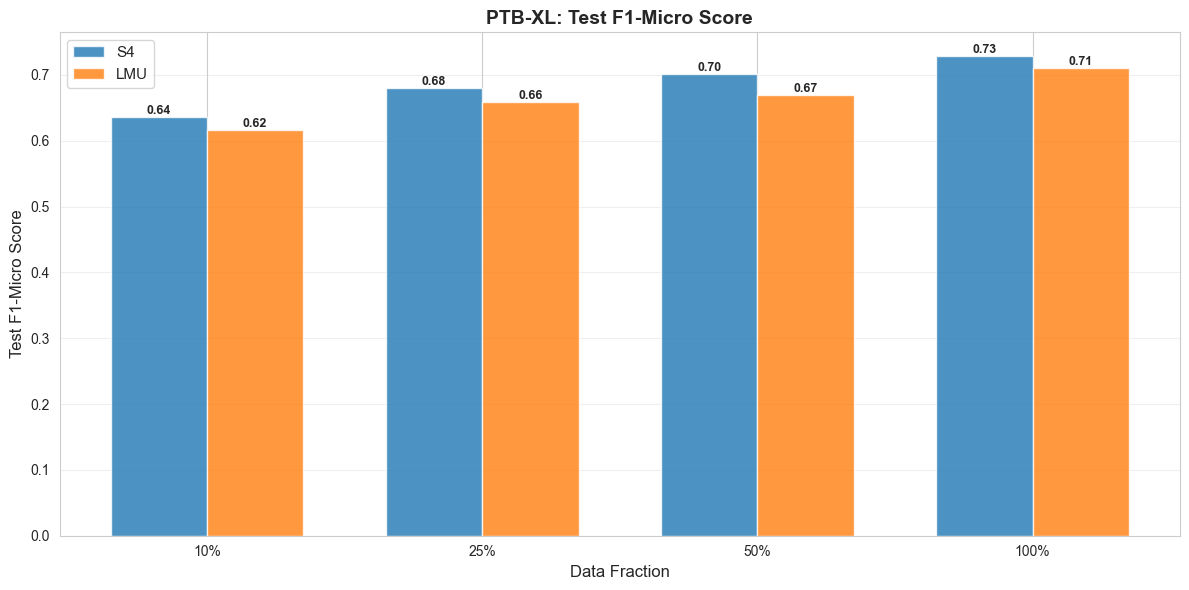

In [4]:
from src.eval.compare import plot_test_metric_comparison

plot_test_metric_comparison(
    all_results,
    metric_key='test_f1_micro',
    title='PTB-XL: Test F1-Micro Score',
    ylabel='Test F1-Micro Score',
)

## 4. Data Efficiency Analysis

Line plot showing how test performance scales with training data size. This reveals which model learns more efficiently from limited data.


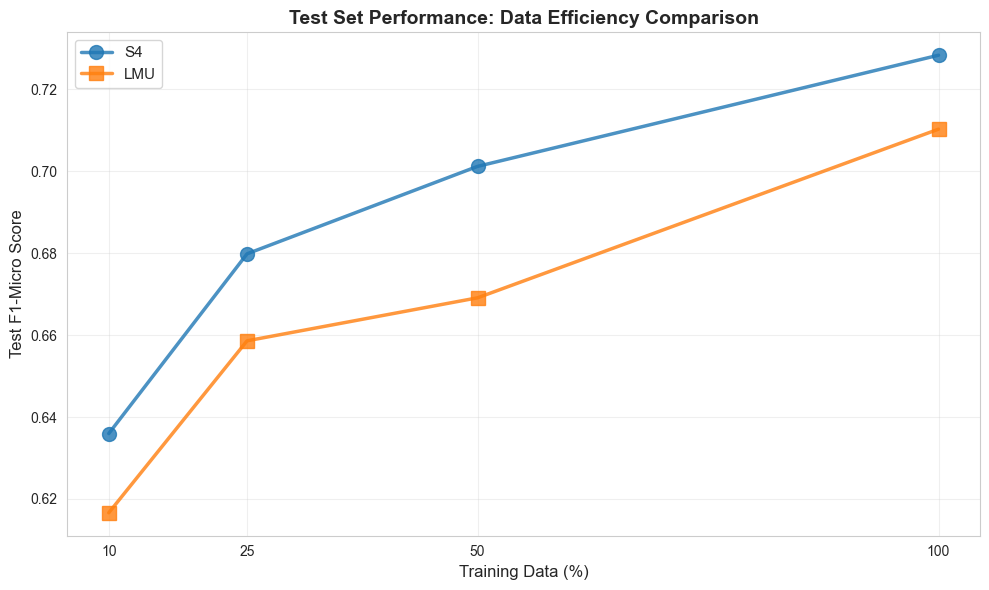

In [5]:
from src.eval.compare import plot_test_data_efficiency

plot_test_data_efficiency(
    all_results,
    metric_key='test_f1_micro',
    ylabel='Test F1-Micro Score'
)

---
## 6. Performance Heatmap

Heatmap showing F1-Micro scores across all model/fraction combinations for easy visual comparison.


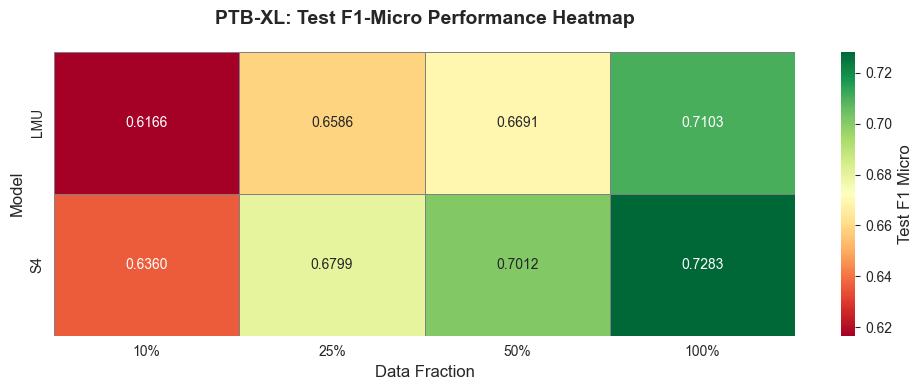

In [6]:
from src.eval.compare import plot_performance_heatmap

plot_performance_heatmap(
    all_results,
    metric_key='test_f1_micro',
    title='PTB-XL: Test F1-Micro Performance Heatmap',
    annot_format='.4f'
)